# Follow a field forward. Follow a gradient backward.

**A PyTorch practical for the PhAST autumn school**

We evolve a one-dimensional diffusion field, compare it with a synthetic
observation, and recover one diffusivity. Every time-step and optimisation
loop is visible. A fixed-grid diffusion model isolates differentiation
through repeated time steps.

This complements the course's elastic-bar inverse toy and scalar
backpropagation example with a spatial field and a parameter reused through
many updates. The final recovery exercise shows one use of that gradient.

**You need:** introductory Python, vectors, derivatives and the chain rule.
**You will learn:** how a fixed discrete update becomes a computational
graph, how reverse mode accumulates a shared parameter's contributions, and
how to check the resulting gradient before using it.

The route is **predict → equation → small code cell → plot → check → recover**.
Work through the cells in order. The example runs on a CPU and generates
its own synthetic observations.

## 1. Prepare the notebook

**Local or Colab:** the notebook is standalone and needs PyTorch, NumPy and
Matplotlib. The next setup cell uses the packages already available in the
current kernel and installs only missing packages. Setup has its own timer
and is excluded from the reported scientific computation time.

**Open in Colab:** download the `.ipynb` file and use Colab's
notebook upload option. Choose a CPU runtime, run the dependency setup cell,
then run the remaining cells. All computations are included in this notebook.
Results use the relative folder `diffusion_results/`, including when the
runtime's working directory is `/content`; download files you want to retain
before the temporary runtime is discarded.

In [1]:
# Dependency bootstrap: use preinstalled packages; install only missing ones.
import importlib.util
import subprocess
import sys
import time

bootstrap_started = time.perf_counter()
required_packages = ("numpy", "matplotlib", "torch")
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "--disable-pip-version-check", *missing_packages])
bootstrap_seconds = time.perf_counter() - bootstrap_started
print({"preinstalled": [name for name in required_packages if name not in missing_packages],
       "installed_now": missing_packages, "bootstrap_seconds": bootstrap_seconds})

{'preinstalled': ['numpy', 'matplotlib', 'torch'], 'installed_now': [], 'bootstrap_seconds': 0.0009873750095721334}


**Five-minute execution budget.** To time a complete Run all, set
`TIMED_RUN_ALL = True` in the next cell. It arms a 285-second watchdog after
dependency setup on Linux/Colab and macOS. The final cell cancels the alarm.
Leave this option off while reading and executing individual cells so that
you can pause between steps. Restart the kernel before retrying a failed run.

In [2]:
import os
import signal

# Set True for a timed Colab Run-all rehearsal; leave off for interactive study.
# The external authoring runner supplies this environment flag for its timed run.
TIMED_RUN_ALL = os.environ.get("DIFFUSION_TIMED_RUN_ALL", "0") == "1"
watchdog_enabled = TIMED_RUN_ALL and hasattr(signal, "SIGALRM")
if TIMED_RUN_ALL and not watchdog_enabled:
    raise RuntimeError("This platform needs an external process timeout for timed execution.")
if watchdog_enabled:
    def stop_timed_run(signum, frame):
        raise TimeoutError("The 285-second scientific Run-all budget was exceeded.")
    signal.signal(signal.SIGALRM, stop_timed_run)
    signal.alarm(285)
science_sequence_started = time.perf_counter()
print({"timed_run_all": TIMED_RUN_ALL, "watchdog_enabled": watchdog_enabled})

{'timed_run_all': True, 'watchdog_enabled': True}


In [3]:
import json
import platform
import sys
import time
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, display

notebook_started = time.perf_counter()
torch.set_default_dtype(torch.float64)
torch.set_default_device("cpu")
torch.set_num_threads(1)
torch.manual_seed(20260909)
OUTPUT_DIR = Path("diffusion_results")
OUTPUT_DIR.mkdir(exist_ok=True)
print({"python": sys.version.split()[0], "torch": torch.__version__,
       "device": "cpu", "dtype": str(torch.get_default_dtype())})

{'python': '3.10.18', 'torch': '2.8.0', 'device': 'cpu', 'dtype': 'torch.float64'}


In [4]:
# Save and embed an already-computed scientific figure.
def show_figure(fig, filename, description):
    fig.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=description))
    plt.close(fig)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
BLUE, ORANGE = "#246fbd", "#d76a20"

## 2. Define the physical problem and the fixed grid

Let $q(x,t)$ be a dimensionless scalar field on $0\leq x\leq 1$. Its ends are held
at zero. The constant diffusivity $\alpha$ controls how quickly spatial variation
smooths out. All quantities in this example are nondimensional.

$$\frac{\partial q}{\partial t}=\alpha\frac{\partial^2 q}{\partial x^2},\qquad q(0,t)=q(1,t)=0.$$

The initial field combines a broad mode with a smaller, finer-scale mode.

$$q(x,0)=\sin(\pi x)+0.25\sin(3\pi x).$$

**Predict:** which mode should fade more quickly? What changes when $\alpha$ grows?
We store only the $M$ interior unknowns; the two boundary values stay fixed.

In [5]:
intervals = 40
x_full = torch.linspace(0.0, 1.0, intervals + 1)
x = x_full[1:-1]
dx = 1.0 / intervals
M = x.numel()
q_initial = torch.sin(torch.pi * x) + 0.25 * torch.sin(3.0 * torch.pi * x)

alpha_min, alpha_max = 0.02, 0.25
dt = 0.40 * dx**2 / alpha_max  # Fixed from the upper diffusivity bound.
N = 80
final_time = N * dt
assert M == 39 and alpha_max * dt / dx**2 <= 0.5
print({"interior_nodes": M, "dx": dx, "dt": dt,
       "steps": N, "final_time": final_time, "maximum_r": alpha_max * dt / dx**2})

{'interior_nodes': 39, 'dx': 0.025, 'dt': 0.0010000000000000002, 'steps': 80, 'final_time': 0.08000000000000002, 'maximum_r': 0.4}


## 3. Write one explicit update

At interior index $i$ and time index $n$, use a centred spatial difference and
forward Euler in time. The bracket is the **dimensionless stencil** $Lq$;
division by $\Delta x^2$ supplies the spatial derivative scale.
The grid coordinate is $x_i=i\Delta x$ and the time is $t_n=n\Delta t$.

$$q_i^{n+1}=q_i^n+\frac{\alpha\Delta t}{\Delta x^2}\left(q_{i-1}^n-2q_i^n+q_{i+1}^n\right).$$

Write $r=\alpha\Delta t/\Delta x^2$. For this one-dimensional diffusion scheme,
$0\leq r\leq 1/2$ is the familiar stability bound. We use a fixed $\Delta t$
that satisfies it for every admissible $\alpha$. Assess grid and time-step
convergence separately from stability.

Boundary padding supplies the prescribed zero values. Each update applies
the three-point stencil directly to the interior field.

In [6]:
def laplace_stencil(q):
    padded = torch.cat((q.new_zeros(1), q, q.new_zeros(1)))
    return padded[:-2] - 2.0 * padded[1:-1] + padded[2:]

alpha_probe = 0.07
q = q_initial
forward_states = [q]
for n in range(N):
    q = q + alpha_probe * dt / dx**2 * laplace_stencil(q)
    forward_states.append(q)
forward_states = torch.stack(forward_states)
assert forward_states.shape == (N + 1, M)

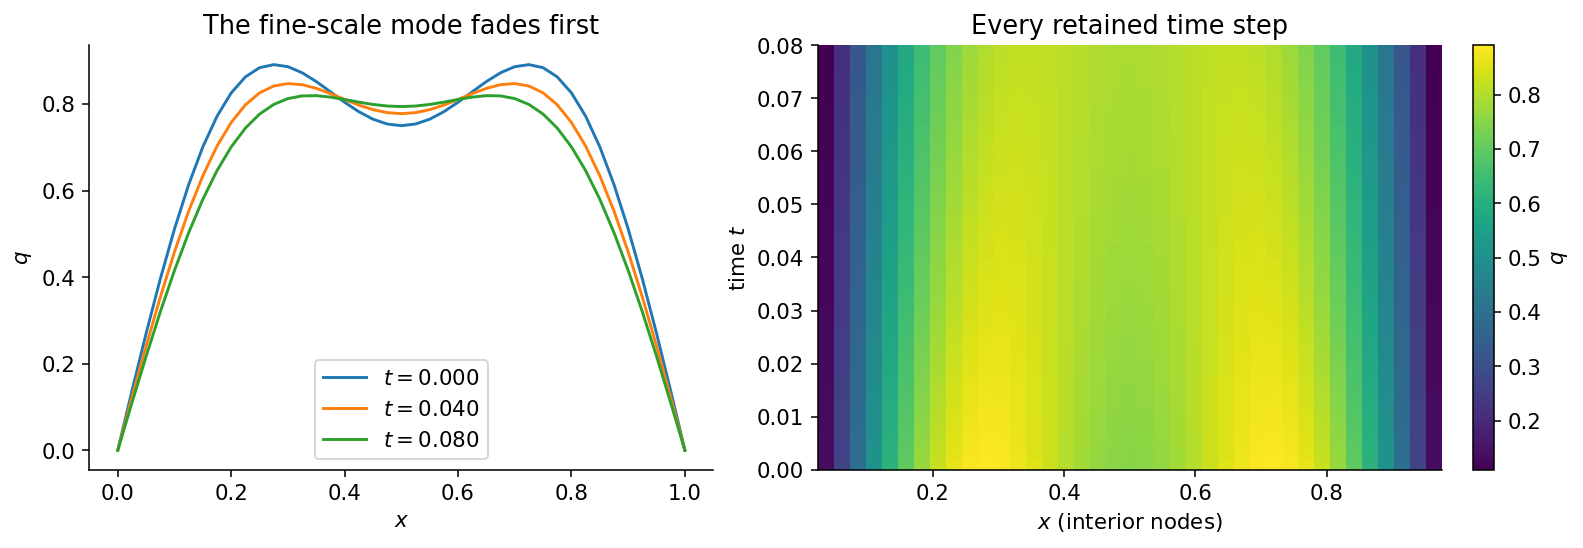

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8), constrained_layout=True)
for n in (0, N // 2, N):
    q_plot = np.pad(forward_states[n].numpy(), (1, 1))
    axes[0].plot(x_full.numpy(), q_plot, label=f"$t = {n * dt:.3f}$")
axes[0].set(xlabel="$x$", ylabel="$q$", title="The fine-scale mode fades first")
axes[0].legend()
evolution_plot = axes[1].imshow(forward_states.numpy(), origin="lower", aspect="auto",
                               extent=(dx, 1 - dx, 0, final_time), cmap="viridis")
axes[1].set(xlabel="$x$ (interior nodes)", ylabel="time $t$", title="Every retained time step")
fig.colorbar(evolution_plot, ax=axes[1], label="$q$")
show_figure(fig, "01_forward.png", "Initial, intermediate and final diffusion fields beside a space-time field map.")

**Change one thing:** try a different coefficient for the third sine mode
in `q_initial`, then restart and run all cells. A zero initial field would
remain zero for every $\alpha$, so the observation has zero sensitivity to $\alpha$.
The exact-mode assertion in the next cell belongs to the stated two-mode
reference input and must be updated when that input changes.

A separate check is available because the discrete sine modes are
eigenvectors of this stencil. Each mode is multiplied by its amplification
factor at every step. Compare the implemented finite-grid update with this
exact discrete recurrence. A refinement study assesses agreement with the
continuum PDE.

In [8]:
r_probe = alpha_probe * dt / dx**2
lambda_1 = -4.0 * np.sin(np.pi / (2 * intervals))**2
lambda_3 = -4.0 * np.sin(3.0 * np.pi / (2 * intervals))**2
mode_reference = ((1.0 + r_probe * lambda_1)**N * torch.sin(torch.pi * x)
                  + 0.25 * (1.0 + r_probe * lambda_3)**N * torch.sin(3.0 * torch.pi * x))
mode_error = float((forward_states[-1] - mode_reference).abs().max())
assert mode_error < 1.0e-12
print({"discrete_mode_max_error": mode_error})

{'discrete_mode_max_error': 3.3306690738754696e-16}


## 4. Turn the final field into a scalar loss

We create a synthetic observation $y$ using the same discretisation at
$\alpha_\star=0.12$. It is fixed during differentiation. The observation includes
every interior node at the final time.

$$y=q^N(\alpha_\star),\qquad J(\alpha)=\frac{1}{2M}\sum_{i=1}^{M}\left(q_i^N(\alpha)-y_i\right)^2.$$

The initial field is known. This example uses noiseless full-field data and
the same discretisation for target and fit.

In [9]:
alpha_true = 0.12
with torch.no_grad():  # Only the fixed synthetic observation is made here.
    target = q_initial
    for n in range(N):
        target = target + alpha_true * dt / dx**2 * laplace_stencil(target)

alpha_sweep = np.linspace(alpha_min, alpha_max, 24)
sweep_fields, sweep_losses = [], []
for alpha_value in alpha_sweep:
    q = q_initial
    for n in range(N):
        q = q + alpha_value * dt / dx**2 * laplace_stencil(q)
    sweep_fields.append(q.numpy())
    sweep_losses.append(float(0.5 * torch.mean((q - target)**2)))

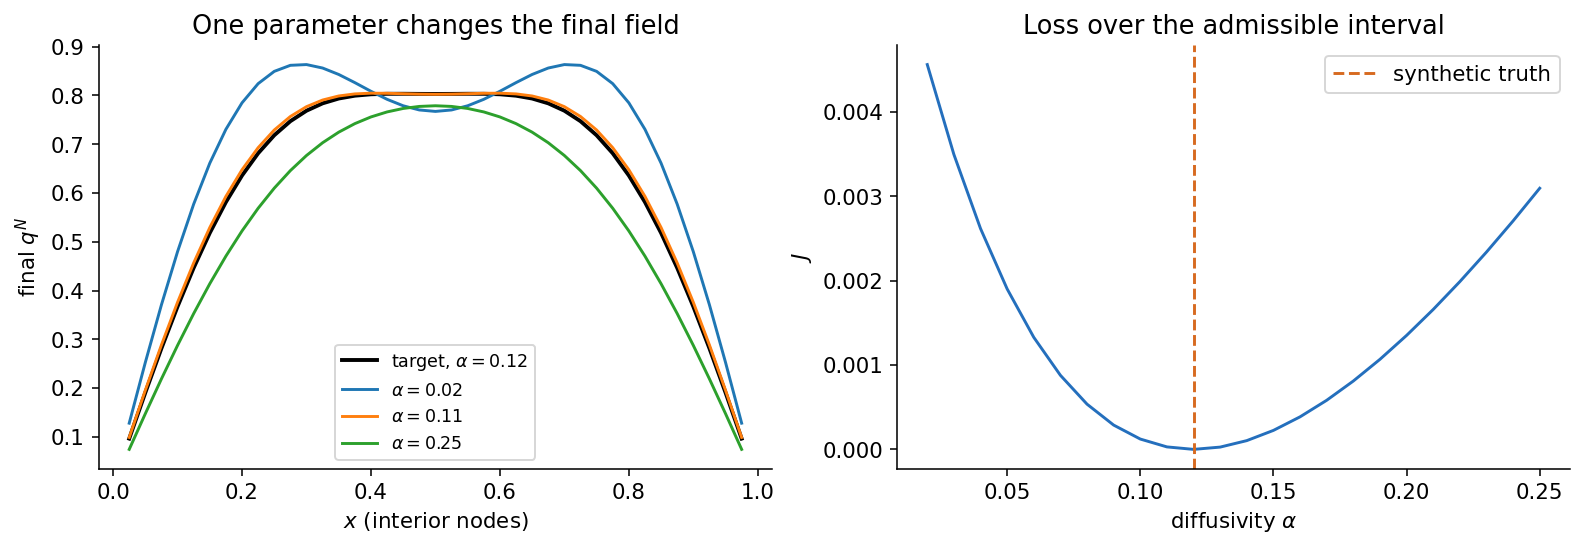

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8), constrained_layout=True)
axes[0].plot(x.numpy(), target.numpy(), color="black", lw=2, label=r"target, $\alpha = 0.12$")
for index in (0, 9, 23):
    axes[0].plot(x.numpy(), sweep_fields[index], label=rf"$\alpha = {alpha_sweep[index]:.2f}$")
axes[0].set(xlabel="$x$ (interior nodes)", ylabel=r"final $q^N$", title="One parameter changes the final field")
axes[0].legend(fontsize=9)
axes[1].plot(alpha_sweep, sweep_losses, color=BLUE)
axes[1].axvline(alpha_true, color=ORANGE, linestyle="--", label="synthetic truth")
axes[1].set(xlabel=r"diffusivity $\alpha$", ylabel="$J$", title="Loss over the admissible interval")
axes[1].legend()
show_figure(fig, "02_parameter_sweep.png", "Final fields at several diffusivities and the corresponding scalar loss curve.")

**Predict:** at $\alpha=0.07$, should $\mathrm{d}J/\mathrm{d}\alpha$ be positive or negative?
Which way would a small gradient-descent step move $\alpha$? Check the loss curve before
running automatic differentiation.

## 5. Ask for a gradient with respect to an input

The graph is $\alpha\to q^1\to\cdots\to q^N\to J$. We also make the initial interior field
an independent input so that its gradient can be compared with the terminal
loss seed. $\alpha$ is reused at all 80 steps. Keep each update as a PyTorch
tensor operation so that the forward loop retains its computational graph.

In [11]:
alpha = torch.tensor(alpha_probe, requires_grad=True)
q0_input = q_initial.clone().requires_grad_(True)
q = q0_input
states = [q]
for n in range(N):
    q = q + alpha * dt / dx**2 * laplace_stencil(q)
    states.append(q)
loss = 0.5 * torch.mean((q - target)**2)

grad_alpha, grad_initial, grad_final = torch.autograd.grad(loss, (alpha, q0_input, q))
ad_gradient = float(grad_alpha)
print({"loss": float(loss.detach()), "dJ_dalpha": ad_gradient,
       "initial_gradient_shape": list(grad_initial.shape),
       "terminal_seed_shape": list(grad_final.shape)})
assert ad_gradient < 0.0

{'loss': 0.0008784004501955788, 'dJ_dalpha': -0.03938567022663596, 'initial_gradient_shape': [39], 'terminal_seed_shape': [39]}


`grad_alpha` is the total derivative of $J$ with respect to $\alpha$ through every
time step. `grad_initial` measures sensitivity to the independent initial
state. `grad_final` is only the derivative of the loss with respect to the
terminal field: $(q^N-y)/M$. This seed is propagated backwards to obtain
the initial-state gradient. The derivative of a final field with respect
to itself is the identity; input sensitivity follows the solved trajectory.

## 6. Reproduce reverse mode, one time step at a time

In vector notation $q^{n+1}=Aq^n$ with $A=I+rL$, where $I$ is the identity. Define the cotangent
$\lambda^n=\partial J/\partial q^n$. For the terminal-only loss above:

$$\lambda^N=\frac{q^N-y}{M},\qquad \lambda^n=A^{\mathsf{T}}\lambda^{n+1}.$$

Each use of the shared parameter contributes a scalar $c_n$:

$$c_n=\left(\lambda^{n+1}\right)^{\mathsf{T}}\frac{\Delta t}{\Delta x^2}Lq^n,\qquad \frac{dJ}{d\alpha}=\sum_{n=0}^{N-1}c_n.$$

Here $L$ is symmetric on the interior degrees of freedom with fixed zero
boundary values. Therefore $A^{\mathsf{T}}\lambda$ can be evaluated with the same stencil.
Each reverse update is a vector–Jacobian product (VJP), evaluated directly
by the stencil. For another spatial discretisation, derive the transposed
action from its actual operator.

In [12]:
# Evaluate the adjoint recurrence directly with numerical tensor arithmetic.
with torch.no_grad():
    adjoint = (states[-1] - target) / M
    contributions = torch.zeros(N)
    for n in reversed(range(N)):
        local_parameter_action = dt / dx**2 * laplace_stencil(states[n])
        contributions[n] = torch.dot(adjoint, local_parameter_action)
        adjoint = adjoint + alpha_probe * dt / dx**2 * laplace_stencil(adjoint)
    manual_gradient = float(contributions.sum())
    adjoint_alpha_error = abs(manual_gradient - ad_gradient)
    adjoint_initial_error = float((adjoint - grad_initial).abs().max())
    terminal_seed_error = float((grad_final - (states[-1] - target) / M).abs().max())

assert adjoint_alpha_error < 1.0e-12
assert adjoint_initial_error < 1.0e-12
assert terminal_seed_error < 1.0e-12
print({"sum_of_step_contributions": manual_gradient,
       "manual_vs_AD_alpha_error": adjoint_alpha_error,
       "manual_vs_AD_initial_error": adjoint_initial_error})

{'sum_of_step_contributions': -0.039385670226635916, 'manual_vs_AD_alpha_error': 4.163336342344337e-17, 'manual_vs_AD_initial_error': 2.168404344971009e-19}


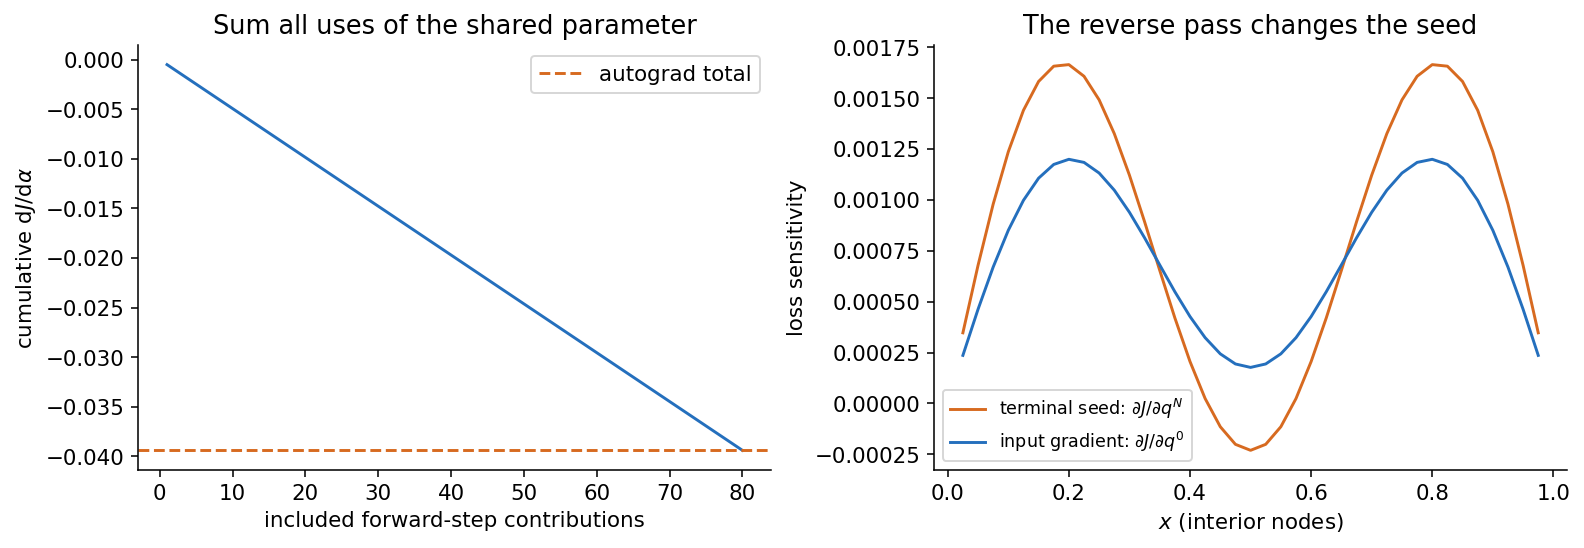

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8), constrained_layout=True)
steps = np.arange(N)
axes[0].plot(steps + 1, np.cumsum(contributions.numpy()), color=BLUE)
axes[0].axhline(ad_gradient, color=ORANGE, linestyle="--", label="autograd total")
axes[0].set(xlabel="included forward-step contributions", ylabel=r"cumulative $\mathrm{d}J/\mathrm{d}\alpha$",
            title="Sum all uses of the shared parameter")
axes[0].legend()
axes[1].plot(x.numpy(), grad_final.numpy(), color=ORANGE, label=r"terminal seed: $\partial J/\partial q^N$")
axes[1].plot(x.numpy(), grad_initial.numpy(), color=BLUE, label=r"input gradient: $\partial J/\partial q^0$")
axes[1].set(xlabel="$x$ (interior nodes)", ylabel="loss sensitivity", title="The reverse pass changes the seed")
axes[1].legend(fontsize=9)
show_figure(fig, "03_reverse_accumulation.png", "Cumulative shared-parameter gradient and a comparison of terminal and initial-state sensitivities.")

The cumulative curve is straight in this special linear, constant-parameter
example: the step operators commute, so the individual $c_n$ are equal up to
rounding. Contributions generally vary in nonlinear or time-varying models.

If $q^0$ depended on $\alpha$, an additional initial-state chain-rule term would be
needed. If the loss directly depended on $\alpha$, its direct derivative would
also contribute. Both terms are zero for the particular inputs defined here.

## 7. Check the derivative at several finite-difference spacings

The centred finite difference is a separate numerical check of the same
scalar function. Keep the grid, time step, number of steps, initial field
and target fixed in both evaluations.

$$D_hJ(\alpha)=\frac{J(\alpha+h)-J(\alpha-h)}{2h}.$$

A large $h$ includes curvature; a very small $h$ can lose significant digits
when two close losses are subtracted. Double precision reduces roundoff;
finite differences still balance truncation and cancellation. Look for
agreement across multiple spacings.

In [14]:
def terminal_loss(alpha_value):
    q = q_initial
    for n in range(N):
        q = q + alpha_value * dt / dx**2 * laplace_stencil(q)
    return 0.5 * torch.mean((q - target)**2)

spacings = np.array([2e-2, 5e-3, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8])
fd_values, fd_relative_errors = [], []
for h in spacings:
    fd = float((terminal_loss(alpha_probe + h) - terminal_loss(alpha_probe - h)) / (2 * h))
    relative_error = abs(fd - ad_gradient) / max(abs(ad_gradient), 1.0e-14)
    fd_values.append(fd)
    fd_relative_errors.append(relative_error)
    print(f"h={h:8.1e}   FD={fd:+.10e}   relative error={relative_error:.3e}")
assert np.count_nonzero(np.array(fd_relative_errors) < 1.0e-5) >= 3

h= 2.0e-02   FD=-4.0362686141e-02   relative error=2.481e-02
h= 5.0e-03   FD=-3.9446489105e-02   relative error=1.544e-03
h= 1.0e-03   FD=-3.9388102357e-02   relative error=6.175e-05
h= 1.0e-04   FD=-3.9385694548e-02   relative error=6.175e-07
h= 1.0e-05   FD=-3.9385670470e-02   relative error=6.174e-09
h= 1.0e-06   FD=-3.9385670228e-02   relative error=2.440e-11
h= 1.0e-07   FD=-3.9385670254e-02   relative error=6.851e-10
h= 1.0e-08   FD=-3.9385670105e-02   relative error=3.086e-09


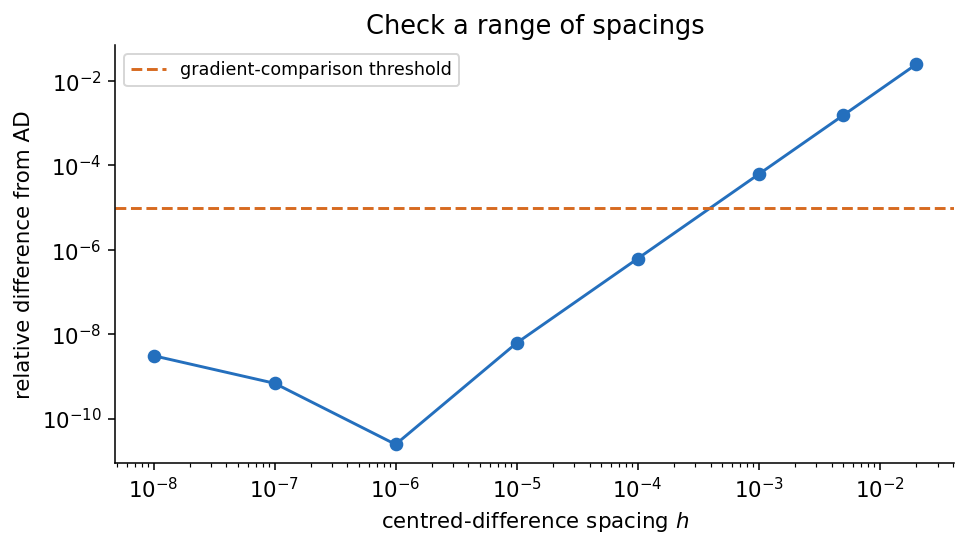

In [15]:
fig, ax = plt.subplots(figsize=(6.8, 3.8), constrained_layout=True)
ax.loglog(spacings, np.maximum(fd_relative_errors, 1e-16), "o-", color=BLUE)
ax.axhline(1.0e-5, color=ORANGE, linestyle="--", label="gradient-comparison threshold")
ax.set(xlabel="centred-difference spacing $h$", ylabel="relative difference from AD",
       title="Check a range of spacings")
ax.legend(fontsize=9)
show_figure(fig, "04_gradient_check.png", "Relative finite-difference versus autograd error across eight spacings.")

## 8. Use the checked gradient to recover $\alpha$

Optimisation is a separate operation from differentiation. We use Adam on
an unconstrained scalar $\theta$ and map it into the stable diffusivity interval:

$$\alpha(\theta)=\alpha_{\min}+(\alpha_{\max}-\alpha_{\min})\frac{1}{1+\exp(-\theta)}.$$

The optimiser receives $\mathrm{d}J/\mathrm{d}\theta$, which includes
$\mathrm{d}\alpha/\mathrm{d}\theta$ by the chain rule. We start at $\alpha=0.21$.
Every iteration recomputes the entire forward trajectory, forms a scalar
loss, calls `backward()`, and then updates $\theta$. The parameter
bounds keep this explicit scheme stable. Identifiability depends on the
initial state and observations. A sigmoid can also make gradients small
near its bounds.

In [16]:
alpha_start = 0.21
fraction = (alpha_start - alpha_min) / (alpha_max - alpha_min)
theta = torch.tensor(np.log(fraction / (1.0 - fraction)), requires_grad=True)
optimizer = torch.optim.Adam([theta], lr=0.10)
optimisation_steps = 220
alpha_history, loss_history = [], []
optimisation_started = time.perf_counter()

for epoch in range(optimisation_steps):
    optimizer.zero_grad(set_to_none=True)
    alpha_fit = alpha_min + (alpha_max - alpha_min) * torch.sigmoid(theta)
    q = q_initial
    for n in range(N):
        q = q + alpha_fit * dt / dx**2 * laplace_stencil(q)
    fit_loss = 0.5 * torch.mean((q - target)**2)
    fit_loss.backward()
    alpha_history.append(float(alpha_fit.detach()))  # Logging only, after the forward pass.
    loss_history.append(float(fit_loss.detach()))
    optimizer.step()
optimisation_seconds = time.perf_counter() - optimisation_started

In [17]:
with torch.no_grad():
    alpha_recovered = float(alpha_min + (alpha_max - alpha_min) * torch.sigmoid(theta))
    initial_prediction, recovered_prediction = q_initial, q_initial
    for n in range(N):
        initial_prediction = initial_prediction + alpha_start * dt / dx**2 * laplace_stencil(initial_prediction)
        recovered_prediction = recovered_prediction + alpha_recovered * dt / dx**2 * laplace_stencil(recovered_prediction)
    final_loss = float(0.5 * torch.mean((recovered_prediction - target)**2))
alpha_history.append(alpha_recovered)
loss_history.append(final_loss)
parameter_relative_error = abs(alpha_recovered - alpha_true) / alpha_true
field_relative_error = float((recovered_prediction - target).norm() / target.norm())
assert parameter_relative_error < 1.0e-3
assert field_relative_error < 1.0e-4
assert final_loss < loss_history[0] * 1.0e-6
print({"true_alpha": alpha_true, "initial_alpha": alpha_start,
       "recovered_alpha": alpha_recovered, "parameter_relative_error": parameter_relative_error,
       "final_field_relative_error": field_relative_error, "final_loss": final_loss,
       "optimisation_seconds": optimisation_seconds})

{'true_alpha': 0.12, 'initial_alpha': 0.21, 'recovered_alpha': 0.12000003329024733, 'parameter_relative_error': 2.7741872780466065e-07, 'final_field_relative_error': 3.805854422723281e-08, 'final_loss': 3.114936182172608e-16, 'optimisation_seconds': 0.9386695419962052}


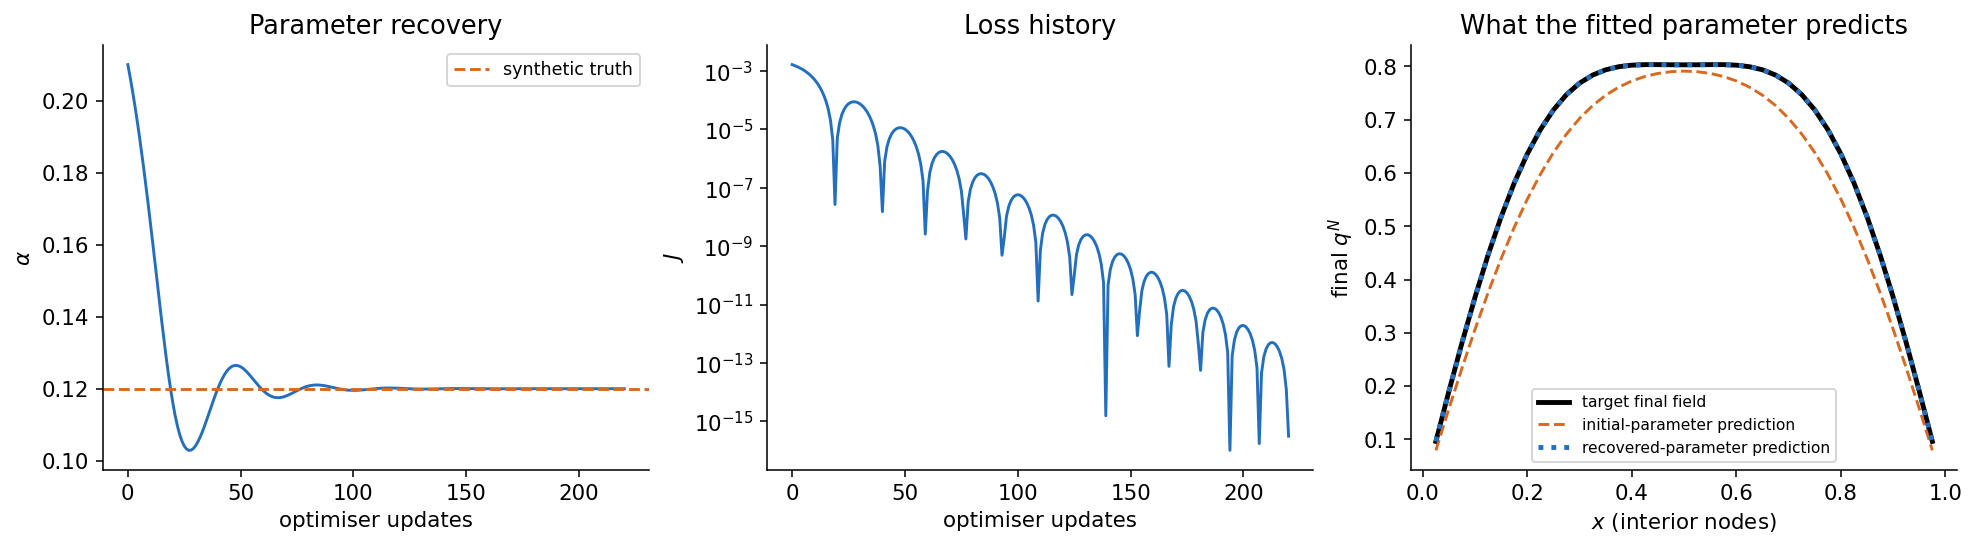

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
epochs = np.arange(len(alpha_history))
axes[0].plot(epochs, alpha_history, color=BLUE)
axes[0].axhline(alpha_true, color=ORANGE, linestyle="--", label="synthetic truth")
axes[0].set(xlabel="optimiser updates", ylabel=r"$\alpha$", title="Parameter recovery")
axes[0].legend(fontsize=9)
axes[1].semilogy(epochs, np.maximum(loss_history, 1e-20), color=BLUE)
axes[1].set(xlabel="optimiser updates", ylabel="$J$", title="Loss history")
axes[2].plot(x.numpy(), target.numpy(), color="black", lw=2.5, label="target final field")
axes[2].plot(x.numpy(), initial_prediction.numpy(), color=ORANGE, linestyle="--", label="initial-parameter prediction")
axes[2].plot(x.numpy(), recovered_prediction.numpy(), color=BLUE, linestyle=":", lw=2.5, label="recovered-parameter prediction")
axes[2].set(xlabel="$x$ (interior nodes)", ylabel=r"final $q^N$", title="What the fitted parameter predicts")
axes[2].legend(fontsize=8)
show_figure(fig, "05_inverse_recovery.png", "Parameter and loss histories plus target, initial-parameter and recovered-parameter final fields.")

## 9. Retain enough information to inspect the result later

The NPZ file contains coordinates, the initial field, the probe trajectory
at `alpha_probe = 0.07`,
target, both fitted-field comparisons, gradient checks and optimisation
histories. The JSON file records the configuration, versions and checks.
PNGs contain the figures. Together these files describe the diffusion
calculation and its parameter-recovery result.

In [19]:
np.savez_compressed(OUTPUT_DIR / "diffusion_fields_and_checks.npz",
    x=x.numpy(), initial_field=q_initial.numpy(), forward_states=forward_states.numpy(),
    target=target.numpy(), initial_prediction=initial_prediction.numpy(),
    recovered_prediction=recovered_prediction.numpy(),
    alpha_history=np.array(alpha_history), loss_history=np.array(loss_history),
    fd_spacings=spacings, fd_values=np.array(fd_values),
    fd_relative_errors=np.array(fd_relative_errors), step_contributions=contributions.numpy())
reloaded = np.load(OUTPUT_DIR / "diffusion_fields_and_checks.npz", allow_pickle=False)
assert np.array_equal(reloaded["recovered_prediction"], recovered_prediction.numpy())
assert reloaded["forward_states"].shape == (N + 1, M)
print({"saved_arrays": sorted(reloaded.files), "reload_check": "passed"})

{'saved_arrays': ['alpha_history', 'fd_relative_errors', 'fd_spacings', 'fd_values', 'forward_states', 'initial_field', 'initial_prediction', 'loss_history', 'recovered_prediction', 'step_contributions', 'target', 'x'], 'reload_check': 'passed'}


## 10. Predict, change, explain

Try the questions before opening the worked answers. Work in a copy when
changing inputs so that you can compare against the original calculation.
Update input-specific assertions together with the assumptions they check.

**Exercise 1.** Why does the gradient with respect to $\alpha$ contain 80 terms,
while the loss has only one terminal observation?

<details><summary>Worked answer — one parameter, many uses</summary>
<p>The same $\alpha$ enters every update. Changing it perturbs $q$ at each step,
and each perturbation can influence the terminal loss. Reverse mode adds
all 80 local parameter contributions after weighting them by the appropriate
downstream cotangent. The terminal observation depends on parameter uses
throughout the trajectory.</p></details>

**Exercise 2.** What would change if the target included a loss at every
time step?

<details><summary>Worked answer — add a local loss seed</summary>
<p>At each reverse step, add the derivative of that step's observation loss
to the cotangent propagated from later steps. The shared-parameter sum still
includes every use of $\alpha$. Its weights now contain contributions from all
later observations.</p></details>

**Exercise 3.** If you double the number of grid intervals while keeping
$\Delta t$ and $\alpha$ fixed, what happens to $r$? How can you preserve stability and the
same final physical time?

<details><summary>Worked answer — refine space and time together</summary>
<p>Halving $\Delta x$ multiplies $r$ by four. Divide $\Delta t$ by four to retain the same $r$,
and multiply $N$ by four to retain the same final time $N\Delta t$. Then rerun the
gradient, accuracy and runtime checks. Compare refined solutions to assess
convergence and measure the extra cost.</p></details>

**Exercise 4.** How does the inverse problem change when $\alpha$ and the
initial field are both unknown and the final observation is noisy?

<details><summary>Worked answer — the inverse question changes</summary>
<p>The current experiment fixes the initial field and uses noiseless,
full-field synthetic observations from the same discretisation. Allowing
the initial field to change can create compensating effects and new
ambiguities. Diffusion also suppresses fine-scale initial information.
Additional observations or prior assumptions would need separate study.</p></details>

## 11. Transfer the reasoning to PhAST

The transferable idea is a defined input → solved state → observable →
scalar loss, followed by a checked VJP. In a fixed-mesh PhAST study, geometry,
connectivity, loads, initial conditions, state variables and the parameter
field must be stated just as explicitly.

A converged implicit subproblem is defined by $R(z,p)=0$. Under
suitable smoothness and nonsingularity assumptions, an adjoint solve gives
a parameter derivative without constructing the full state Jacobian inverse:

$$R_z^{\mathsf{T}}\lambda=\nabla_z J.$$

$$\nabla_p\widehat{J}=\nabla_p J-R_p^{\mathsf{T}}\lambda.$$

Here $z$ collects the implicit unknowns, $p$ is an input parameter vector,
$R$ is the residual vector, and $J$ is a scalar loss. Write
$R_z=\partial R/\partial z$ and $R_p=\partial R/\partial p$.
All gradients and the adjoint $\lambda$ are column vectors. The reduced
loss is $\widehat{J}(p)=J(z(p),p)$; on the right, $\nabla_p J$ holds $z$ fixed
and $\nabla_z J$ holds $p$ fixed. The displayed formula treats
$z$ as the implicit state of the stated residual;
a complete history requires all relevant state and parameter dependencies.
A converged implicit derivative and a derivative through a fixed number of
iterations answer different computational questions.

Fracture also has history maxima, irreversibility bounds, changing active
sets, and potentially failed or tolerance-dependent nonlinear solves. At a
switch or crack event, a derivative may be branch-dependent, nonsmooth or
unsuitable for the intended inverse question. Assess both local smoothness
and forward-solve accuracy. Check converged forward fields and
residuals, then compare directional AD and finite differences across several
spacings while recording the active-set/history behaviour.

## Provenance and further reading

Original equations, code, plots and exercises were written for this course.
Pedagogical inspiration: Ceyron's [first data-assimilation practical](https://github.com/Ceyron/hybridization-in-jax/blob/61ee2629f5800d92fba64492a0f81efe3a6a7c39/practical_session/first_data_assimilation.ipynb),
version `61ee2629f5800d92fba64492a0f81efe3a6a7c39`.
Its short explanation/equation/code/plot sequence is the closest reference;
the repository's second practical and its accompanying video concern neural
hybrid correction. The diffusion formulation and PyTorch implementation
here were written for the course.

The companion book develops the same reverse-recurrence and implicit-adjoint
ideas in *Backpropagation through a stepped update*.

In [20]:
measured_cell_seconds = time.perf_counter() - notebook_started
scientific_sequence_seconds = time.perf_counter() - science_sequence_started
if watchdog_enabled:
    signal.alarm(0)
    assert scientific_sequence_seconds < 300.0
metrics = {
    "schema": "ukacm-diffusion-differentiability-v1",
    "scope": "Original fixed-grid explicit 1D diffusion model with synthetic full-field observations",
    "environment": {"python": sys.version.split()[0], "python_executable_name": Path(sys.executable).name,
                    "torch": torch.__version__, "numpy": np.__version__,
                    "matplotlib": plt.matplotlib.__version__, "platform": platform.platform(),
                    "device": "cpu", "dtype": "float64", "threads": torch.get_num_threads()},
    "configuration": {"intervals": intervals, "interior_nodes": M, "dx": dx,
                      "dt": dt, "steps": N, "final_time": final_time,
                      "alpha_bounds": [alpha_min, alpha_max], "alpha_probe": alpha_probe,
                      "alpha_true": alpha_true, "alpha_start": alpha_start,
                      "optimisation_steps": optimisation_steps, "seed": 20260909,
                      "boundary_conditions": "q(0,t)=q(1,t)=0; interior degrees of freedom only",
                      "maximum_diffusion_ratio": alpha_max * dt / dx**2,
                      "stability_bound": "0 <= alpha*dt/dx**2 <= 0.5",
                      "saved_forward_states_parameter": alpha_probe},
    "checks": {"discrete_mode_max_error": mode_error, "AD_gradient": ad_gradient,
               "manual_gradient": manual_gradient, "manual_AD_parameter_error": adjoint_alpha_error,
               "manual_AD_initial_state_error": adjoint_initial_error,
               "terminal_seed_error": terminal_seed_error,
               "fd_spacings": spacings.tolist(), "fd_relative_errors": fd_relative_errors,
               "alpha_recovered": alpha_recovered, "parameter_relative_error": parameter_relative_error,
               "field_relative_error": field_relative_error, "initial_loss": loss_history[0],
               "final_loss": final_loss, "array_reload_passed": True, "all_assertions_passed": True},
    "cell_sequence_seconds_after_imports": measured_cell_seconds,
    "scientific_sequence_seconds_after_bootstrap_including_imports": scientific_sequence_seconds,
    "dependency_bootstrap": {"seconds": bootstrap_seconds, "installed_packages": missing_packages,
                             "used_preinstalled_packages": not missing_packages},
    "timed_run_all": TIMED_RUN_ALL,
    "watchdog_enabled": watchdog_enabled,
    "optimisation_seconds": optimisation_seconds,
    "timing_note": "Bootstrap measured separately. In interactive use, sequence elapsed time includes human pauses; only timed Run-all enforces the scientific watchdog. External receipt includes kernel startup/imports and subtracts dependency bootstrap.",
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2) + "\n")
print({"all_assertions_passed": True, "alpha_recovered": alpha_recovered,
       "scientific_sequence_seconds_after_bootstrap": scientific_sequence_seconds,
       "dependency_bootstrap_seconds": bootstrap_seconds, "timed_run_all": TIMED_RUN_ALL,
       "artifacts": str(OUTPUT_DIR)})

{'all_assertions_passed': True, 'alpha_recovered': 0.12000003329024733, 'scientific_sequence_seconds_after_bootstrap': 4.445852500008186, 'dependency_bootstrap_seconds': 0.0009873750095721334, 'timed_run_all': True, 'artifacts': 'diffusion_results'}
